In [1]:
!python -m spacy download el_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 34.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('el_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
nlp = spacy.load('el_core_news_sm')

In [5]:
efsyn_df = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/Notebooks εργασίας/EFSYN/efsyn_full_articles_df_cleaned.csv')
efsyn_df.head()

,Article No,link,title,category,date,author,summary,full_text
0,1,https://www.efsyn.gr/politiki/1402509/ntilian-...,Ντίλιαν: Συμπληρώθηκαν οι υπογραφές για κλήση ...,Βουλή,2026-06-10 14:31:00,Ολυμπία Λιάτσου,"Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι...","Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι..."
1,2,https://www.efsyn.gr/stiles/1402187/press-poin...,"Press Point: Νικήτα Κακλαμάνη, πάρε τα 2/5 και...",Απόψεις,2026-06-10 09:27:00,ΕΝΤΥΠΗ ΕΚΔΟΣΗΔημήτρης Κανελλόπουλος,NaN,Παλεύουν κάποιοι να βρουν άκρη με το θέμα τωνυ...
2,3,https://www.efsyn.gr/kosmos/1401911/tramp-oi-i...,Τραμπ: «Οι Ιρανοί κατέρριψαν το ελικόπτερο Apa...,Βόρεια Αμερική,2026-06-09 19:52:00,efsyn.gr,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...
3,4,https://www.efsyn.gr/politiki/1401961/epimenei...,Επιμένει ο Φλωρίδης για τις υποκλοπές: «Δεν υπ...,Παρασκήνια,2026-06-09 18:46:00,efsyn.gr,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...
4,5,https://www.efsyn.gr/politiki/1401876/ypoklope...,Υποκλοπές: Αυξάνεται η πίεση στο Μαξίμου μετά ...,Αντιπολίτευση,2026-06-09 17:10:00,efsyn.gr,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...


In [6]:
tanea_df = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/Notebooks εργασίας/TA NEA/tanea_df_2025-26.csv')
tanea_df

,site,url,headline,category,author,date,full_text
0,tanea.gr,https://www.tanea.gr/2026/06/09/politics/tsouk...,Απάντηση Τσουκαλά σε Φλωρίδη: Να ανασυρθεί από...,Πολιτική,NaN,2026-06-09 16:39:00,Έντονη κριτική στην κυβέρνησημε αφορμή τις δηλ...
1,tanea.gr,https://www.tanea.gr/2026/06/07/politics/ypokl...,Υποκλοπές: Νέα πολιτική θύελλα μετά τις αποκαλ...,Πολιτική,NaN,2026-06-07 16:38:00,Έντονους κραδασμούς στο κυβερνητικό στρατόπεδο...
2,tanea.gr,https://www.tanea.gr/2026/06/04/politics/maksi...,Μαξίμου για αίτημα ΠΑΣΟΚ να κληθεί στη Βουλή ο...,Πολιτική,Ελένη Ευαγγελοδήμου,2026-06-04 13:20:00,Για τηστάση της κυβέρνησης μπροστά στο αίτημα ...
3,tanea.gr,https://www.tanea.gr/2026/06/04/greece/ypoklop...,Υποκλοπές: Ντόμινο εξελίξεων μετά τις δηλώσεις...,Ελλάδα,Μίνα Μουστάκα,2026-06-04 12:24:00,Νέα δεδομένα στηνπολύκροτη υπόθεση των τηλεφων...
4,tanea.gr,https://www.tanea.gr/2026/06/02/politics/ypokl...,Υποκλοπές: Αίτημα του ΠΑΣΟΚ για ακρόαση στην Ε...,Πολιτική,NaN,2026-06-02 17:03:00,Αίτημαγια ακρόαση τωνΤαλ ΝτίλιανκαιΓρηγόρη Δημ...
...,...,...,...,...,...,...,...
136,tanea.gr,https://www.tanea.gr/2025/10/22/politics/andro...,Ανδρουλάκης: Θα πάμε την υπόθεση του Predator ...,Πολιτική,NaN,2025-10-22 17:47:00,Μετά την ολοκλήρωση της κατάθεσης του στη δίκη...
137,tanea.gr,https://www.tanea.gr/2025/08/24/science-techno...,Νέοι κίνδυνοι για την ιδιωτικότητα από τα ραντάρ,Επιστήμη & Τεχνολογία,Γιώργος Μαζιάς,2025-08-24 18:27:00,Μια νέα τεχνολογία υποκλοπής φέρνει στο προσκή...
138,tanea.gr,https://www.tanea.gr/2025/07/22/politics/epane...,Επανέρχεται στο δικαστικό προσκήνιο η υπόθεση ...,Πολιτική,Μίνα Μουστάκα,2025-07-22 12:04:00,Στο δικαστικό προσκήνιο επανέρχεται η υπόθεση ...
139,tanea.gr,https://www.tanea.gr/2025/02/11/greece/ypoklop...,Υποκλοπές: «Όχι» από Άρειο Πάγο σε Ανδρουλάκη ...,Ελλάδα,Μίνα Μουστάκα,2025-02-11 14:28:00,Με το σκεπτικό ότι η υπόθεση των τηλεφωνικών υ...


In [9]:
efsyn_text = efsyn_df['full_text'].str.cat(sep = ' ')
efsyn_text[:665]

'Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επιτροπή μπορεί να καλεί σε ακρόαση λειτουργούς του κράτους, καθώς και οποιοδήποτε δημόσιο πρόσωπο για θέματα που αφορούν στη λειτουργία των θεσμών και της διαφάνειας, η προσέλευση των οποίων είναι υποχρεωτική». Παρότι συμπληρώθηκε ο απαιτούμενος αριθμός των 2/5 των μελών της που προβλέπει ο κανονισμός, και καθιστά πλέον υποχρεωτική την κλήση του προς ακρόαση, είναι άγνωστο εάν η Επιτροπή Θεσμών και Διαφάνειας της Βουλής θα καλέσει σε ακρόαση τον επιχειρηματίαΤαλ Ντίλιαν, προκειμένου να δώσει απαντήσεις στο σκάνδαλο τωνυποκλοπώνκαι το παράνομο λογισμικό predator, μετά τα αιτήματα που έχει υποβάλει η αντιπολίτευση. '

In [10]:
tanea_text = tanea_df['full_text'].str.cat(sep = ' ')
tanea_text[:665]

'Έντονη κριτική στην κυβέρνησημε αφορμή τις δηλώσεις του υπουργού Δικαιοσύνης Γιώργου Φλωρίδη(«Παραπολιτικά») για την υπόθεση των παρακολουθήσεων ασκεί σε δήλωσή του ο εκπρόσωπος Τύπου του ΠΑΣΟΚ Κώστας Τσουκαλάς.\nΟ υπουργός ανέφερε ότι«η δικαιοσύνη κατέληξε σε ποινικές ευθύνες ιδιωτών. Εκείνο το πόρισμα έκρινε ότι δεν υπάρχει εμπλοκή κρατικών υπηρεσιών. Όποιος νομίζει ότι έχει κάτι άλλο, η Δικαιοσύνη είναι εκεί και περιμένει», τονίζει ο κ. Τσουκαλάς, διερωτώμενοςαν ο υπουργός γνωρίζει ότι η υπόθεσηαρχειοθετήθηκε παρά την ύπαρξη νέων στοιχείων που προέκυψαν από το Μονομελές Πλημμελειοδικείο.\nΔιαβάστε επίσης: Σκάνδαλο υποκλοπών: Τα «κρυφά χαρτιά» του Ντίλιαν\nΠ'

In [12]:
two_sites_list = [] # φτιάχνω μια λίστα για να βάλω μέσα τα dictionaries που φτιάχνω παρακάτω
efsynD = {'site' : 'efsyn.gr', 'text' : efsyn_text} # φτιάχνω dictionary 1
two_sites_list.append(efsynD) # βάζω το dictionary στη λίστα
taneaD = {'site' : 'tanea.gr', 'text' : tanea_text} # φτιάχνω dictionary 2
two_sites_list.append(taneaD) # βάζω το dictionary στη λίστα
two_sites_df = pd.DataFrame(two_sites_list) # φτιάχνω dataframe από τη λίστα με τα δύο dictionaries
two_sites_df

Output hidden; open in https://colab.research.google.com to view.

In [13]:
tfidf_vectorizer = TfidfVectorizer(stop_words= list(nlp.Defaults.stop_words), max_features=500)
tfidf_matrix_train = tfidf_vectorizer.fit_transform(two_sites_df['text'])

In [14]:
arr = cosine_similarity(tfidf_matrix_train, tfidf_matrix_train)
print("cosine scores ==> ", arr)

cosine scores ==>  [[1.         0.95633041]
 [0.95633041 1.        ]]


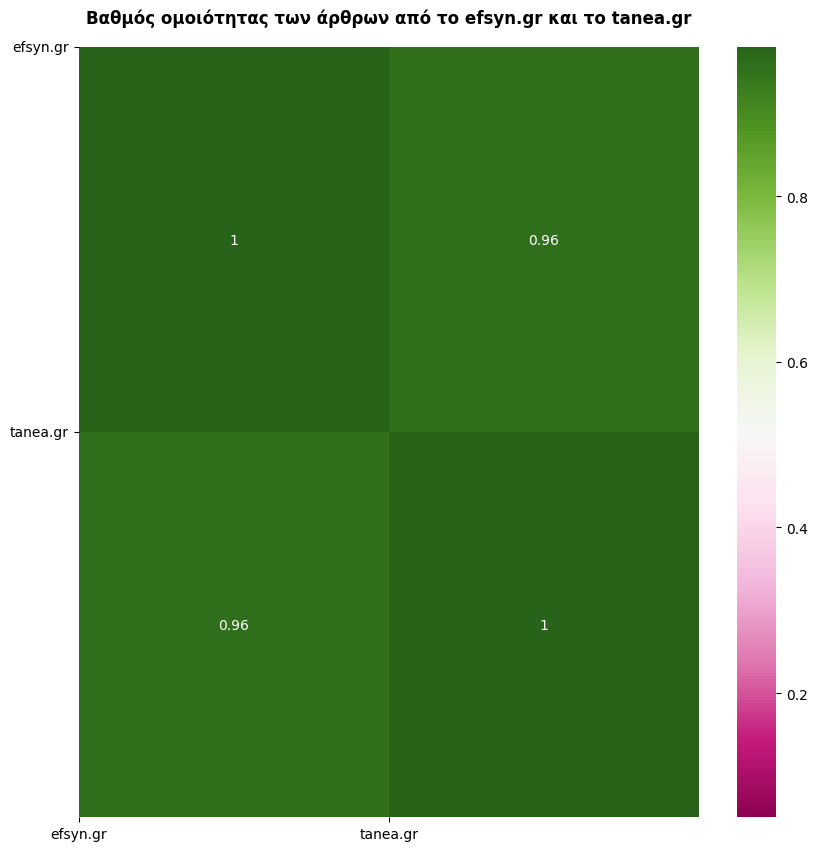

In [15]:
plt.figure(figsize=(10, 10))
plt.title('Βαθμός ομοιότητας των άρθρων από το efsyn.gr και το tanea.gr', y=1.02, fontweight='bold') # το y ορίζει την απόσταση του τίτλου από το γράφημα
sns.heatmap(data=arr, annot=True, vmin=0.05, vmax=0.98, cmap="PiYG") # το vmin και το vmax ορίζουν πάνω και κάτω από ποιο αριθμό ομοιότητας θα εμφανίζεται το ντεγκραντέ των δύο ακραίων χρωμάτων
plt.xticks([0, 1], ['efsyn.gr', 'tanea.gr']) # ορίζω να εμφανίζονται τα ονόματα των sites αντί για το 0 και 1 του index, στον άξονα x
plt.yticks([0, 1], ['efsyn.gr', 'tanea.gr'], rotation=0) # ορίζω να εμφανίζονται τα ονόματα των sites αντί για το 0 και 1 του index, στον άξονα y - με το rotation=0 κάνω τα ονόματα των sites στον άξονα y να εμφανίζονται οριζόντια
plt.savefig('Cosine similarity in two sites.png') # αποθηκεύω την εικόνα του γραφήματος στο drive

